In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Simulation

In [2]:
ntrials = 100000
theta = (np.random.random(ntrials) - 0.5) * np.pi
dfo = np.random.random(ntrials) ** 0.5
pts = np.column_stack((np.sin(theta), np.cos(theta))) * np.expand_dims(dfo, 1)
closer_to_diam = pts[:, 1] < 1-np.sqrt(np.sum(pts ** 2, axis=1))
print(np.mean(closer_to_diam))

0.4214


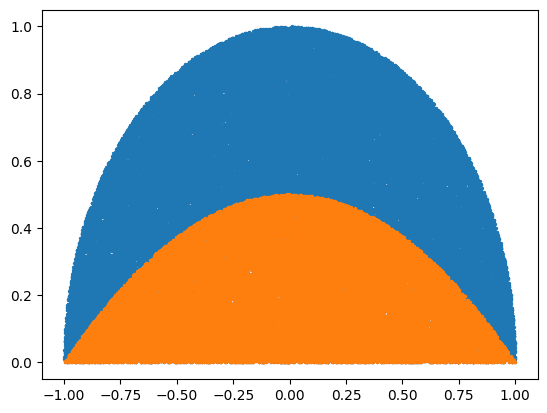

In [3]:
# Plot simulated points (orange = Diametric Beach closer)
plt.scatter(pts[:, 0], pts[:, 1], s=2)
plt.scatter(pts[:, 0][closer_to_diam], pts[:, 1][closer_to_diam], s=2)
plt.show()

### Math
##### Assume beach radius == 1.  Each possible point defined by:
>###### Angle (Θ) from point (0, 0) - between -π/2 and +π/2, uniformly distributed
>###### Distance (d) from (0, 0) - between 0 and 1, distributed such that p(d < x) = x ** 2
##### Distance to Diametric Beach (Dd) 
>###### = d.cos(Θ) [vertical distance from x axis]
##### Distance to Semi-Circle Beach (Ds)
>###### = 1 - d
##### Point is closer to Diametric Beach where:
>###### Dd < Ds
>###### d.cos(Θ) < 1 - d
>###### d + d.cos(Θ) < 1
>###### d(1 + cos(Θ)) < 1
>###### d < 1 / (1 + cos(Θ))

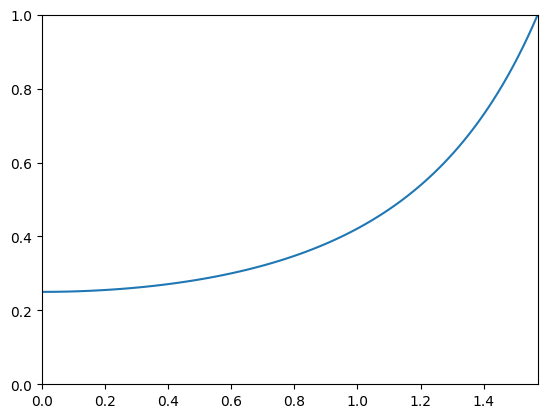

In [4]:
# Plot 1 / (1 + cos(Θ)) for range of values of Θ
n = 100
tx = np.arange(n+1) / n * np.pi / 2
ty = (1 / (1 + np.cos(tx))) ** 2

plt.plot(tx, ty)
plt.xlim(0, np.pi/2)
plt.ylim(0, 1)
plt.show()

##### Total probability of being closer to Diametric Beach = Area under curve / Total area
##### Area under curve:
>###### Integral of 1 / (1 + cos(Θ)) for Θ == 0 -> π/2
>###### = (tan(Θ/2)/2) + ((tan(Θ/2)**3) / 6)
>###### = (tan(π/4)/2) + ((tan(π/4)**3) / 6)
>###### = 1/2 + 1/6
>###### = 2/3
##### Total area 
>######     = π/2
##### Total probability of being closer to Diametric Beach 
>######     = (2/3) / (pi/2) 
>######     = 4 / 3pi 
>######     ~= 0.424413